**Spark Classification Model with Logistic Regression**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import rand

# 1. Initialize Spark Session
spark = SparkSession.builder.appName("SparkClassificationModel").getOrCreate()

print("Spark Session Initialized.")

# 2. Generate a synthetic dataset (simple example)
# Let's create a dataset with two features and a binary label
data = spark.range(0, 1000).toDF("id")\
    .withColumn("feature1", rand(seed=42) * 10)\
    .withColumn("feature2", rand(seed=24) * 5)

# Create a binary label based on a simple rule
data = data.withColumn("label", ((data["feature1"] + data["feature2"]) > 7).cast("double"))

print("\nSynthetic Data Sample:")
data.show(5)

# 3. Prepare the data for Spark ML (VectorAssembler)
# Combine feature columns into a single vector column
feature_columns = ["feature1", "feature2"]
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data_transformed = vector_assembler.transform(data)

print("\nData with Feature Vector Sample:")
data_transformed.select("features", "label").show(5)

# 4. Split data into training and testing sets
(training_data, testing_data) = data_transformed.randomSplit([0.8, 0.2], seed=1234)

print(f"\nTraining data count: {training_data.count()}")
print(f"Testing data count: {testing_data.count()}")

# 5. Choose a classification model (Logistic Regression)
lrm = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)

# 6. Train the model
print("\nTraining the Logistic Regression model...")
lrm_model = lrm.fit(training_data)
print("Model training complete.")

# 7. Make predictions on the test data
predictions = lrm_model.transform(testing_data)

print("\nPredictions Sample:")
predictions.select("features", "label", "prediction", "probability").show(5)

# 8. Evaluate the model
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"\nTest set accuracy = {accuracy:.4f}")

# You can also get other metrics like F1-score
f1_score = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
print(f"Test set F1-score = {f1_score:.4f}")

# Stop Spark Session
spark.stop()
print("\nSpark Session stopped.")

Spark Session Initialized.

Synthetic Data Sample:
+---+-----------------+------------------+-----+
| id|         feature1|          feature2|label|
+---+-----------------+------------------+-----+
|  0| 6.19189370225301|1.9716276984763774|  1.0|
|  1|5.096018842446481| 2.430996219097051|  1.0|
|  2|8.325259388871524|1.4619758202762139|  1.0|
|  3|2.632280904117236|1.6667658316640088|  0.0|
|  4|6.702867696264136| 1.990969872927459|  1.0|
+---+-----------------+------------------+-----+
only showing top 5 rows

Data with Feature Vector Sample:
+--------------------+-----+
|            features|label|
+--------------------+-----+
|[6.19189370225301...|  1.0|
|[5.09601884244648...|  1.0|
|[8.32525938887152...|  1.0|
|[2.63228090411723...|  0.0|
|[6.70286769626413...|  1.0|
+--------------------+-----+
only showing top 5 rows

Training data count: 790
Testing data count: 210

Training the Logistic Regression model...
Model training complete.

Predictions Sample:
+--------------------+----

**Spark K-Means Clustering with Kaggle Dataset (Wholesale Customers Data)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# Install the Kaggle library
!pip install kaggle

In [2]:

import kagglehub
smitisinghal_wholesale_customers_data_path = kagglehub.dataset_download('smitisinghal/wholesale-customers-data')

print('Data source import complete.')


100%|██████████| 6.85k/6.85k [00:00<00:00, 11.5MB/s]

Extracting files...
Data source import complete.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv("/content/Wholesale customers data.csv")

In [5]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Spark Session
if 'spark' in globals() and spark: # Check if 'spark' variable exists and is not None
    spark.stop()
spark = SparkSession.builder.appName("WholesaleCustomerClustering").getOrCreate()
print("Spark Session Initialized.")

# Convert Pandas DataFrame to Spark DataFrame
spark_df = spark.createDataFrame(df)
print("\nSpark DataFrame Schema:")
spark_df.printSchema()
spark_df.show(5)

Spark Session Initialized.

Spark DataFrame Schema:
root
 |-- Channel: long (nullable = true)
 |-- Region: long (nullable = true)
 |-- Fresh: long (nullable = true)
 |-- Milk: long (nullable = true)
 |-- Grocery: long (nullable = true)
 |-- Frozen: long (nullable = true)
 |-- Detergents_Paper: long (nullable = true)
 |-- Delicassen: long (nullable = true)

+-------+------+-----+----+-------+------+----------------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|
+-------+------+-----+----+-------+------+----------------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|
|      2|     3|22615|5410|   7198|  3915|            1777|      5185|
+-------+------+-----+----+-------+------+----------------+----------+
on

In [6]:
feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Assemble features into a single vector column
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data_vector = vector_assembler.transform(spark_df)

# Scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(data_vector)
data_scaled = scaler_model.transform(data_vector)

print("\nData with scaled features sample:")
data_scaled.select("features", "scaledFeatures").show(5)


Data with scaled features sample:
+--------------------+--------------------+
|            features|      scaledFeatures|
+--------------------+--------------------+
|[12669.0,9656.0,7...|[0.05287300424153...|
|[7057.0,9810.0,95...|[-0.3908570560636...|
|[6353.0,8808.0,76...|[-0.4465209837997...|
|[13265.0,1196.0,4...|[0.09999757942718...|
|[22615.0,5410.0,7...|[0.83928411967191...|
+--------------------+--------------------+
only showing top 5 rows


Now, we will apply the K-Means clustering algorithm. We'll start with `k=3` clusters, similar to the previous synthetic data example, but you can explore different values for `k` if needed. After clustering, we'll evaluate the model using the Silhouette Score.

In [7]:
num_clusters = 3  # You can adjust the number of clusters
kmeans = KMeans(featuresCol="scaledFeatures", k=num_clusters, seed=42)
model = kmeans.fit(data_scaled)

# Make predictions
predictions = model.transform(data_scaled)

# Evaluate clustering using Silhouette Score
evaluator = ClusteringEvaluator(featuresCol="scaledFeatures", metricName="silhouette")
silhouette = evaluator.evaluate(predictions)

print(f"\nSilhouette Score with K={num_clusters}: {silhouette:.4f}")

print("\nCluster Centers:")
centers = model.clusterCenters()
for i, center in enumerate(centers):
    print(f"Cluster {i+1} Center: {center}")

predictions.select("Channel", "Region", "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen", "prediction").show(5)


Silhouette Score with K=3: 0.7405

Cluster Centers:
Cluster 1 Center: [ 0.00909578 -0.22343196 -0.25210288  0.00324867 -0.24883295 -0.07617343]
Cluster 2 Center: [-0.12329595  1.84139049  2.17872849 -0.18161621  2.19098694  0.30116938]
Cluster 3 Center: [ 1.96458102  5.16961846  1.28575327  6.89275382 -0.55423109 16.45971129]
+-------+------+-----+----+-------+------+----------------+----------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|prediction|
+-------+------+-----+----+-------+------+----------------+----------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|         0|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|         0|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|         0|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|         0|
|      2|     3|22615|5410|   7198|  3915|            1777|      5185|         0|
+-------+------

/tmp/ipykernel_6759/3883573909.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prediction', data=predictions_pd, palette='viridis')


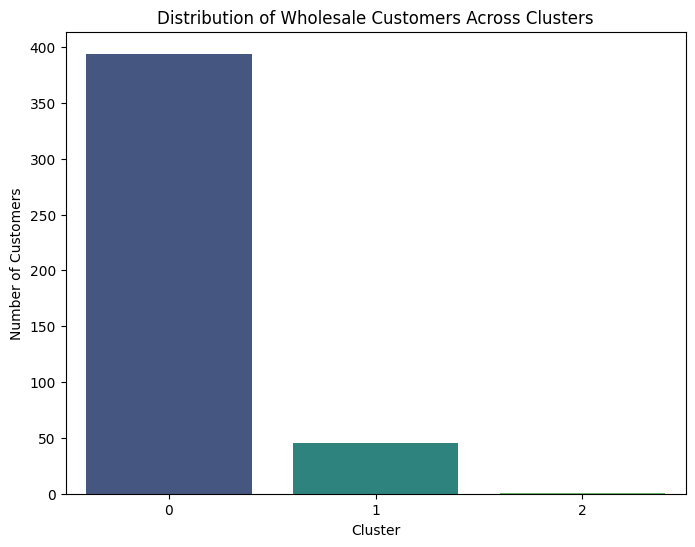


Spark Session stopped.


In [8]:
# Convert Spark predictions DataFrame to Pandas DataFrame for easier visualization
predictions_pd = predictions.toPandas()

# Plot the distribution of clusters
plt.figure(figsize=(8, 6))
sns.countplot(x='prediction', data=predictions_pd, palette='viridis')
plt.title('Distribution of Wholesale Customers Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

# Stop Spark Session
spark.stop()
print("\nSpark Session stopped.")

In [16]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Ensure a fresh Spark Session
try:
    spark.stop()
except Exception as e:
    # print(f"Spark session stop failed (possibly not running): {e}")
    pass # Ignore error if spark was already stopped or not initialized

spark = SparkSession.builder.appName("WholesaleCustomerClustering").getOrCreate()
print("Spark Session Re-initialized.")

# Convert Pandas DataFrame to Spark DataFrame again, as the session might have been restarted
spark_df = spark.createDataFrame(df)

feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Assemble features into a single vector column
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data_vector = vector_assembler.transform(spark_df)

# Scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(data_vector)
data_scaled = scaler_model.transform(data_vector)

print("\nData with scaled features sample:")
data_scaled.select("features", "scaledFeatures").show(5)

Spark Session Re-initialized.

Data with scaled features sample:
+--------------------+--------------------+
|            features|      scaledFeatures|
+--------------------+--------------------+
|[12669.0,9656.0,7...|[0.05287300424153...|
|[7057.0,9810.0,95...|[-0.3908570560636...|
|[6353.0,8808.0,76...|[-0.4465209837997...|
|[13265.0,1196.0,4...|[0.09999757942718...|
|[22615.0,5410.0,7...|[0.83928411967191...|
+--------------------+--------------------+
only showing top 5 rows


In [17]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

num_clusters = 3  # You can adjust the number of clusters
kmeans = KMeans(featuresCol="scaledFeatures", k=num_clusters, seed=42)
model = kmeans.fit(data_scaled)

# Make predictions
predictions = model.transform(data_scaled)

# Evaluate clustering using Silhouette Score
evaluator = ClusteringEvaluator(featuresCol="scaledFeatures", metricName="silhouette")
silhouette = evaluator.evaluate(predictions)

print(f"\nSilhouette Score with K={num_clusters}: {silhouette:.4f}")

print("\nCluster Centers:")
centers = model.clusterCenters()
for i, center in enumerate(centers):
    print(f"Cluster {i+1} Center: {center}")

predictions.select("Channel", "Region", "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen", "prediction").show(5)


Silhouette Score with K=3: 0.7405

Cluster Centers:
Cluster 1 Center: [ 0.00909578 -0.22343196 -0.25210288  0.00324867 -0.24883295 -0.07617343]
Cluster 2 Center: [-0.12329595  1.84139049  2.17872849 -0.18161621  2.19098694  0.30116938]
Cluster 3 Center: [ 1.96458102  5.16961846  1.28575327  6.89275382 -0.55423109 16.45971129]
+-------+------+-----+----+-------+------+----------------+----------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|prediction|
+-------+------+-----+----+-------+------+----------------+----------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|         0|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|         0|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|         0|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|         0|
|      2|     3|22615|5410|   7198|  3915|            1777|      5185|         0|
+-------+------

/tmp/ipykernel_6759/727614997.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prediction', data=predictions_pd, palette='viridis')


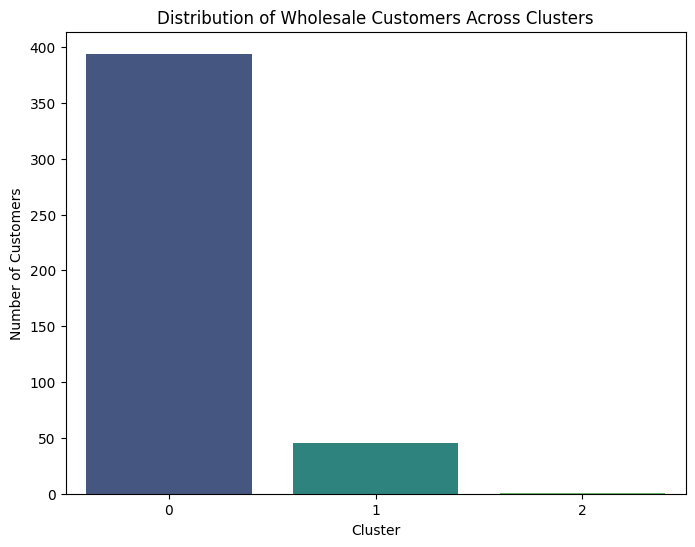

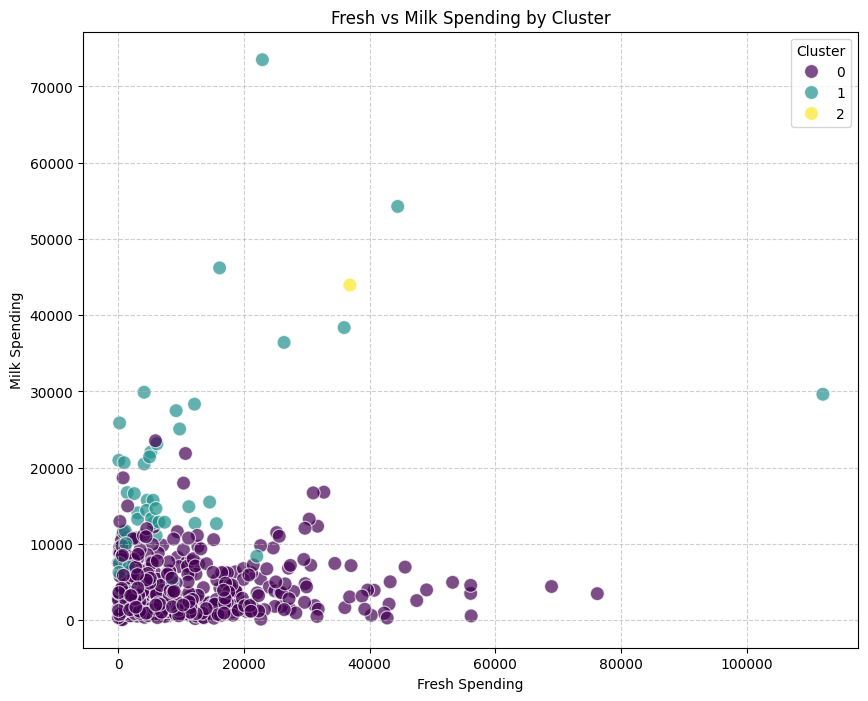


Spark Session stopped.


In [18]:
# Convert Spark predictions DataFrame to Pandas DataFrame for easier visualization
predictions_pd = predictions.toPandas()

# Plot the distribution of clusters
plt.figure(figsize=(8, 6))
sns.countplot(x='prediction', data=predictions_pd, palette='viridis')
plt.title('Distribution of Wholesale Customers Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

# Plot Fresh vs Milk spending, colored by cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Fresh', y='Milk', hue='prediction', data=predictions_pd, palette='viridis', s=100, alpha=0.7)
plt.title('Fresh vs Milk Spending by Cluster')
plt.xlabel('Fresh Spending')
plt.ylabel('Milk Spending')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Stop Spark Session
spark.stop()
print("\nSpark Session stopped.")